# Multiplane ABCD closure and significance scans

This notebook follows the table layout used in `testK/python/AN-25-092_gridsearch.py`, but reads the signal from reweighted pickle files using the `SignalReweighter.region_sums` method developed in `limitcalc_oop`.

The default use case is a private stop sample generated at nominal cτ, reweighted to the true cτ implied by its mass, mass gap, and private-production BR. C1N2 samples are not lifetime-reweighted: for C1N2 the target cτ is set equal to the generated cτ.

Assumptions are hardcoded: use 2018 inputs only, skip `GT0`, scan `GT1`, `GT2`, and `GT3`, and scale all yields by `4.59637` to approximate the 2017-2023 total.

In [67]:
from ctypes import c_double
from pathlib import Path
from types import SimpleNamespace
import importlib.util
import math
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import ROOT
from uncertainties import ufloat

ROOT.gROOT.SetBatch(True)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})

In [68]:
PLOTTER = Path("/users/alikaan.gueven/AOD_to_nanoAOD/Plotter_run3/CMSSW_15_0_5/src/SoftDisplacedVertices/Plotter")
LIMITCALC_OOP = PLOTTER / "limitcalc" / "limitcalc_oop"
sys.path.insert(0, str(LIMITCALC_OOP))

reweighted_script = LIMITCALC_OOP / "AN-25-092_make_reweighted_pkl_datacards.py"
spec = importlib.util.spec_from_file_location("reweighted_pkl_datacards", reweighted_script)
reweighted = importlib.util.module_from_spec(spec)
spec.loader.exec_module(reweighted)

SignalReweighter = reweighted.SignalReweighter
import utils


In [69]:
PLOT_OUTDIR = Path("/users/alikaan.gueven/AOD_to_nanoAOD/Plotter_run3/CMSSW_15_0_5/src/SoftDisplacedVertices/Plotter/ABCD_optimisation/plots")
PLOT_OUTDIR.mkdir(parents=True, exist_ok=True)

In [70]:
YEAR = "2018"
PLANES = ["GT1", "GT2", "GT3"]
YIELD_SCALE = 4.59637

BKG_ROOT = Path("/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/AN-25-092_ML_plots_limitcalc_merge_w_Ang_v3_centralprod/bkg_2018/bkg_2018_hist.root")
SIG_DIR = Path("/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/AN-25-092_ML_plots_limitcalc_privateprod_260527/sig_2018")

# Private stop sample: generated at ct=0.2, reweighted to the true stop ctau.
# SIGNAL_PKL = SIG_DIR / "stopML_M1000_975_ct0p2_2018_hist0.pkl"
SIGNAL_PKL = SIG_DIR / "C1N2ML_M500_485_ct200_2018_hist0.pkl"
ORIGIN_BR = 1.0  # private stop samples were generated with BR=1.0; ignored for C1N2

sample_info = utils.parse_signal_name(reweighted.source_sample_name(SIGNAL_PKL))
ORIGIN_CTAU = sample_info.ct

if sample_info.model == "stop":
    TARGET_CTAU = utils.get_stop_ctau_for_br(sample_info.M, sample_info.dM, ORIGIN_BR)
    TARGET_BR = ORIGIN_BR
elif sample_info.model == "C1N2":
    TARGET_CTAU = ORIGIN_CTAU
    TARGET_BR = None
else:
    raise ValueError(f"Unsupported signal model: {sample_info.model}")

print(f"Signal: {sample_info.name}")
print(f"model={sample_info.model}, M={sample_info.M}, dM={sample_info.dM}")
print(f"ctau: generated={ORIGIN_CTAU:g} mm, target={TARGET_CTAU:g} mm")

X_LO = 250.0
Y_LO = 0.80
X_EDGES = np.arange(300.0, 701.0, 50.0)
Y_EDGES = np.round(np.arange(0.9900, 0.9999, 0.0002), 5)

assert BKG_ROOT.exists(), BKG_ROOT
assert SIGNAL_PKL.exists(), SIGNAL_PKL


Signal: C1N2ML_M500_485_ct200
model=C1N2, M=500, dM=15
ctau: generated=200 mm, target=200 mm


## Table helpers

In [71]:
TABLE_NAMES = [
    "sig_NA", "sig_NB", "sig_NC", "sig_ND",
    "bkg_NA", "bkg_NB", "bkg_NC", "bkg_ND",
    "sig_NA_unc", "sig_NB_unc", "sig_NC_unc", "sig_ND_unc",
    "bkg_NA_unc", "bkg_NB_unc", "bkg_NC_unc", "bkg_ND_unc",
    "Z_A", "Z_B", "Z_C", "Z_D",
    "Z_A_pred", "Z_noncl_A_pred",
    "Z_noncl_A", "Z_noncl_B", "Z_noncl_C", "Z_noncl_D",
    "noncl", "noncl_unc",
    "A_pred", "A_pred_unc",
    "delta_A", "delta_A_unc",
]


def empty_tables(x_edges=X_EDGES, y_edges=Y_EDGES):
    empty = pd.DataFrame(index=pd.Index(np.round(x_edges, 8)), columns=pd.Index(np.round(y_edges, 8)), dtype=float)
    return {name: empty.copy() for name in TABLE_NAMES}


def calc_unc(bkg_n, bkg_unc, noncl=None):
    unc1 = bkg_n * 0.10
    unc2 = bkg_n * noncl if noncl else 0.0
    unc3 = bkg_unc
    return np.sqrt(unc1**2 + unc2**2 + unc3**2)
    


def scaled_ufloat(value, error, scale=YIELD_SCALE):
    return ufloat(value, error) * scale


def yield_uncertainty_for_table(value, zero_unc=1.0):
    return zero_unc if value.n == 0 else value.s


def yields_for_delta_a(yld, zero_unc=1.0):
    return {
        region: ufloat(0.0, zero_unc) if value.n < 0 else ufloat(value.n, yield_uncertainty_for_table(value, zero_unc))
        for region, value in yld.items()
    }


def fill_yield_tables(tables, prefix, yld, x_cut, y_cut):
    for region in ["A", "B", "C", "D"]:
        tables[f"{prefix}_N{region}"].loc[x_cut, y_cut] = yld[region].n
        tables[f"{prefix}_N{region}_unc"].loc[x_cut, y_cut] = yield_uncertainty_for_table(yld[region])


import math
safe_Z = lambda z: 0.0 if not math.isfinite(z) else z


def fill_significance_tables(tables, sig, bkg, x_cut, y_cut):
    eps = 0.5

    sig_NA, sig_NB, sig_NC, sig_ND = sig["A"], sig["B"], sig["C"], sig["D"]
    bkg_NA, bkg_NB, bkg_NC, bkg_ND = bkg["A"], bkg["B"], bkg["C"], bkg["D"]

    Z_A = safe_Z(ROOT.RooStats.AsimovSignificance(sig_NA.n, max(eps, bkg_NA.n), calc_unc(max(eps, bkg_NA.n), max(eps, bkg_NA.s), 0.0)))
    Z_B = safe_Z(ROOT.RooStats.AsimovSignificance(sig_NB.n, max(eps, bkg_NB.n), calc_unc(max(eps, bkg_NB.n), max(eps, bkg_NB.s), 0.0)))
    Z_C = safe_Z(ROOT.RooStats.AsimovSignificance(sig_NC.n, max(eps, bkg_NC.n), calc_unc(max(eps, bkg_NC.n), max(eps, bkg_NC.s), 0.0)))
    Z_D = safe_Z(ROOT.RooStats.AsimovSignificance(sig_ND.n, max(eps, bkg_ND.n), calc_unc(max(eps, bkg_ND.n), max(eps, bkg_ND.s), 0.0)))

    tables["Z_A"].loc[x_cut, y_cut] = Z_A
    tables["Z_B"].loc[x_cut, y_cut] = Z_B
    tables["Z_C"].loc[x_cut, y_cut] = Z_C
    tables["Z_D"].loc[x_cut, y_cut] = Z_D

    A_pred = tables["A_pred"].loc[x_cut, y_cut]
    A_pred_unc = tables["A_pred_unc"].loc[x_cut, y_cut]
    A_pred_n = max(eps, A_pred) if np.isfinite(A_pred) else eps
    A_pred_s = max(eps, A_pred_unc) if np.isfinite(A_pred_unc) else eps
    noncl = tables["noncl"].loc[x_cut, y_cut]
    noncl = abs(noncl) if np.isfinite(noncl) else 0.0

    Z_A_pred = safe_Z(ROOT.RooStats.AsimovSignificance(sig_NA.n, A_pred_n, calc_unc(A_pred_n, A_pred_s, 0.0)))
    Z_noncl_A_pred = safe_Z(ROOT.RooStats.AsimovSignificance(sig_NA.n, A_pred_n, calc_unc(A_pred_n, A_pred_s, noncl)))

    Z_noncl_A = safe_Z(ROOT.RooStats.AsimovSignificance(sig_NA.n, max(eps, bkg_NA.n), calc_unc(max(eps, bkg_NA.n), max(eps, bkg_NA.s), noncl)))
    Z_noncl_B = safe_Z(ROOT.RooStats.AsimovSignificance(sig_NB.n, max(eps, bkg_NB.n), calc_unc(max(eps, bkg_NB.n), max(eps, bkg_NB.s), noncl)))
    Z_noncl_C = safe_Z(ROOT.RooStats.AsimovSignificance(sig_NC.n, max(eps, bkg_NC.n), calc_unc(max(eps, bkg_NC.n), max(eps, bkg_NC.s), noncl)))
    Z_noncl_D = safe_Z(ROOT.RooStats.AsimovSignificance(sig_ND.n, max(eps, bkg_ND.n), calc_unc(max(eps, bkg_ND.n), max(eps, bkg_ND.s), noncl)))

    tables["Z_A_pred"].loc[x_cut, y_cut] = Z_A_pred
    tables["Z_noncl_A_pred"].loc[x_cut, y_cut] = Z_noncl_A_pred
    tables["Z_noncl_A"].loc[x_cut, y_cut] = Z_noncl_A
    tables["Z_noncl_B"].loc[x_cut, y_cut] = Z_noncl_B
    tables["Z_noncl_C"].loc[x_cut, y_cut] = Z_noncl_C
    tables["Z_noncl_D"].loc[x_cut, y_cut] = Z_noncl_D


In [72]:
def background_yields(hist, x_cut, y_cut):
    x_lo = hist.GetXaxis().FindBin(X_LO)
    x_up = hist.GetNbinsX() + 1
    x_bound = hist.GetXaxis().FindBin(x_cut)

    y_lo = hist.GetYaxis().FindBin(Y_LO)
    y_up = hist.GetNbinsY() + 1
    y_bound = hist.GetYaxis().FindBin(y_cut)

    err = c_double(0.0)
    return {
        "A": scaled_ufloat(hist.IntegralAndError(x_bound, x_up, y_bound, y_up, err), err.value),
        "B": scaled_ufloat(hist.IntegralAndError(x_lo, x_bound - 1, y_bound, y_up, err), err.value),
        "C": scaled_ufloat(hist.IntegralAndError(x_bound, x_up, y_lo, y_bound - 1, err), err.value),
        "D": scaled_ufloat(hist.IntegralAndError(x_lo, x_bound - 1, y_lo, y_bound - 1, err), err.value),
    }


def signal_yields(reweighter, plane, x_cut, y_cut):
    options = SimpleNamespace(xcut=x_cut, xlo=X_LO, ycut=y_cut, ylo=Y_LO)
    values, errors = reweighter.region_sums(plane, options, TARGET_BR, TARGET_CTAU)
    return {region: ufloat(values[region], errors[region]) * YIELD_SCALE for region in ["A", "B", "C", "D"]}


def fill_closure_tables(tables, bkg, x_cut, y_cut):
    fill_yield_tables(tables, "bkg", bkg, x_cut, y_cut)

    denom = bkg["A"] * bkg["D"]
    noncl_raw = 1.0 - (bkg["B"] * bkg["C"]) / denom if denom.n > 0 else ufloat(1.0, 1.0)
    noncl = ufloat(abs(noncl_raw.n), noncl_raw.s)
    A_pred = (bkg["B"] * bkg["C"]) / bkg["D"] if bkg["D"].n > 0 else ufloat(float("nan"), float("nan"))

    bkg_for_delta = yields_for_delta_a(bkg)
    A_pred_for_delta = (bkg_for_delta["B"] * bkg_for_delta["C"]) / bkg_for_delta["D"] if bkg_for_delta["D"].n > 0 else ufloat(float("nan"), float("nan"))
    delta_A = bkg_for_delta["A"] - A_pred_for_delta if bkg_for_delta["D"].n > 0 else ufloat(float("nan"), float("nan"))

    tables["noncl"].loc[x_cut, y_cut] = noncl.n
    tables["noncl_unc"].loc[x_cut, y_cut] = noncl.s
    tables["A_pred"].loc[x_cut, y_cut] = A_pred.n
    tables["A_pred_unc"].loc[x_cut, y_cut] = A_pred.s
    tables["delta_A"].loc[x_cut, y_cut] = delta_A.n
    tables["delta_A_unc"].loc[x_cut, y_cut] = delta_A.s


def make_tables_for_plane(bkg_hist, plane, reweighter=None):
    tables = empty_tables()

    for x_cut in X_EDGES:
        for y_cut in Y_EDGES:
            if x_cut < X_LO or y_cut < Y_LO:
                continue

            bkg = background_yields(bkg_hist, x_cut, y_cut)
            fill_closure_tables(tables, bkg, x_cut, y_cut)

            if reweighter is None:
                continue

            sig = signal_yields(reweighter, plane, x_cut, y_cut)
            fill_yield_tables(tables, "sig", sig, x_cut, y_cut)
            fill_significance_tables(tables, sig, bkg, x_cut, y_cut)

    return tables


## Build scan tables

In [73]:
bkg_file = ROOT.TFile.Open(str(BKG_ROOT))
if not bkg_file or bkg_file.IsZombie():
    raise FileNotFoundError(BKG_ROOT)

closure_tables = {}

try:
    for plane in PLANES:
        hist = bkg_file.Get(f"{plane}_evt/MET_pt_corr_vs_leadingvtx_MLscore")
        if not hist:
            raise KeyError(f"Missing background histogram for {plane}")
        closure_tables[plane] = make_tables_for_plane(hist, plane)
finally:
    bkg_file.Close()

list(closure_tables), closure_tables["GT1"].keys()


/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


(['GT1', 'GT2', 'GT3'],
 dict_keys(['sig_NA', 'sig_NB', 'sig_NC', 'sig_ND', 'bkg_NA', 'bkg_NB', 'bkg_NC', 'bkg_ND', 'sig_NA_unc', 'sig_NB_unc', 'sig_NC_unc', 'sig_ND_unc', 'bkg_NA_unc', 'bkg_NB_unc', 'bkg_NC_unc', 'bkg_ND_unc', 'Z_A', 'Z_B', 'Z_C', 'Z_D', 'Z_A_pred', 'Z_noncl_A_pred', 'Z_noncl_A', 'Z_noncl_B', 'Z_noncl_C', 'Z_noncl_D', 'noncl', 'noncl_unc', 'A_pred', 'A_pred_unc', 'delta_A', 'delta_A_unc']))

Error in <THashList::Delete>: A list is accessing an object (0x55d3f2e103d0) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d3efbb3b70) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d3f3ef53c0) already deleted (list name = THashList)


The significance table uses `SignalReweighter.region_sums`, so the signal pickle must contain `MET_pt_corr` and `leadingvtx_MLscore` in addition to `evt_weight` and the LLP cτ fields. The private-production pickles under `AN-25-092_ML_plots_limitcalc_privateprod_260527` have these columns.

In [74]:
bkg_file = ROOT.TFile.Open(str(BKG_ROOT))
if not bkg_file or bkg_file.IsZombie():
    raise FileNotFoundError(BKG_ROOT)

signal = SignalReweighter(SIGNAL_PKL, ORIGIN_CTAU, origin_br=ORIGIN_BR)
significance_tables = {}

try:
    for plane in PLANES:
        hist = bkg_file.Get(f"{plane}_evt/MET_pt_corr_vs_leadingvtx_MLscore")
        if not hist:
            raise KeyError(f"Missing background histogram for {plane}")
        significance_tables[plane] = make_tables_for_plane(hist, plane, reweighter=signal)
finally:
    bkg_file.Close()

list(significance_tables), significance_tables["GT1"].keys()


/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")
/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")


(['GT1', 'GT2', 'GT3'],
 dict_keys(['sig_NA', 'sig_NB', 'sig_NC', 'sig_ND', 'bkg_NA', 'bkg_NB', 'bkg_NC', 'bkg_ND', 'sig_NA_unc', 'sig_NB_unc', 'sig_NC_unc', 'sig_ND_unc', 'bkg_NA_unc', 'bkg_NB_unc', 'bkg_NC_unc', 'bkg_ND_unc', 'Z_A', 'Z_B', 'Z_C', 'Z_D', 'Z_A_pred', 'Z_noncl_A_pred', 'Z_noncl_A', 'Z_noncl_B', 'Z_noncl_C', 'Z_noncl_D', 'noncl', 'noncl_unc', 'A_pred', 'A_pred_unc', 'delta_A', 'delta_A_unc']))

Error in <THashList::Delete>: A list is accessing an object (0x55d3f2e66720) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d3efb30370) already deleted (list name = THashList)
Error in <THashList::Delete>: A list is accessing an object (0x55d3efbdca90) already deleted (list name = THashList)


## Plot helpers

In [75]:
def pick_ticks(vals, n=6):
    vals = np.asarray(list(vals), dtype=float)
    if len(vals) <= n:
        return vals
    idx = np.unique(np.round(np.linspace(0, len(vals) - 1, n)).astype(int))
    idx[0] = 0
    idx[-1] = len(vals) - 1
    return vals[idx]


def edges_from_centers(c):
    c = np.asarray(c, dtype=float)
    d = np.diff(c)
    e = np.empty(len(c) + 1)
    e[1:-1] = c[:-1] + d / 2
    e[0] = c[0] - d[0] / 2
    e[-1] = c[-1] + d[-1] / 2
    return e


def heatmap(ax, df, title, cbar_label, cmap, vmin=None, vmax=None):
    x = df.index.to_numpy(dtype=float)
    y = df.columns.to_numpy(dtype=float)
    c = np.ma.masked_invalid(df.T.to_numpy(dtype=float))

    pcm = ax.pcolormesh(edges_from_centers(x), edges_from_centers(y), c, cmap=cmap, vmin=vmin, vmax=vmax, shading="flat")
    ax.set_xticks(pick_ticks(x, 6))
    ax.set_yticks(pick_ticks(y, 6))
    ax.set_xticklabels([f"{v:g}" for v in ax.get_xticks()], rotation=45, ha="right")
    ax.set_yticklabels([f"{v:.5f}" for v in ax.get_yticks()])
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.5f"))
    ax.set_xlabel("MET cut")
    ax.set_ylabel("ML cut")
    ax.set_title(title)
    cbar = ax.figure.colorbar(pcm, ax=ax, shrink=0.85)
    cbar.ax.set_ylabel(cbar_label)
    return pcm

## Closure scans

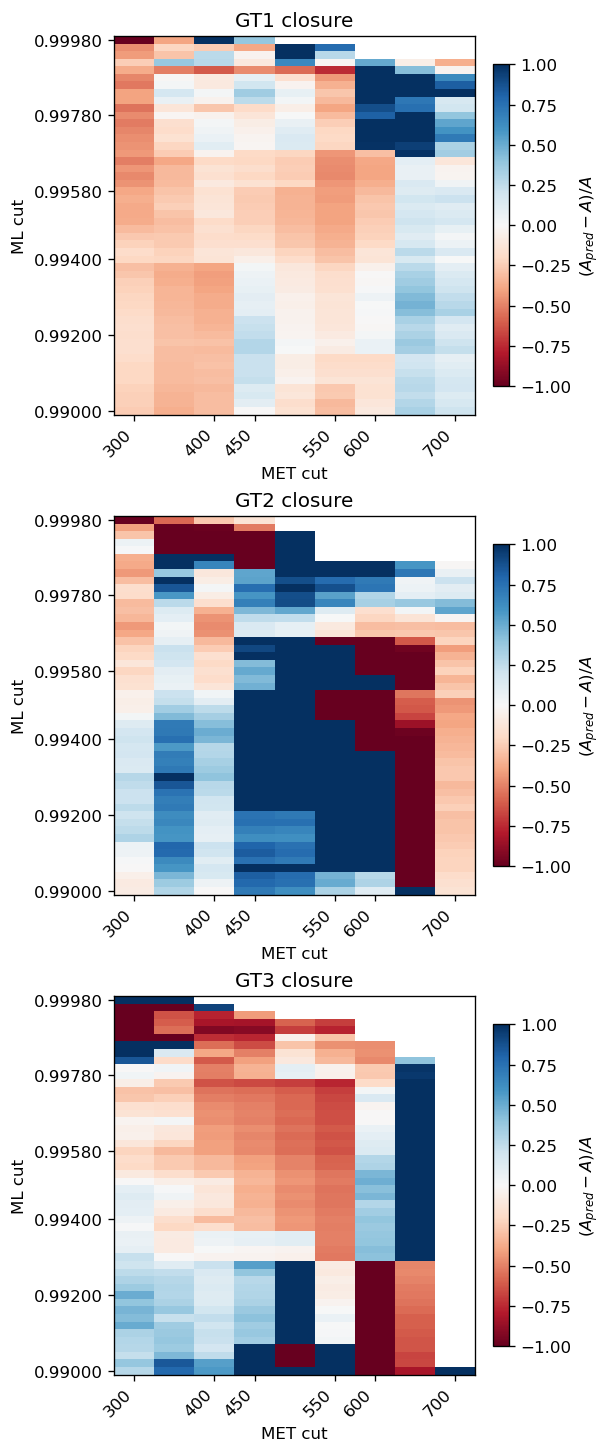

In [76]:
fig, axes = plt.subplots(3, 1, figsize=(5, 12), constrained_layout=True)

for ax, plane in zip(axes, PLANES):
    closure = -closure_tables[plane]["delta_A"] / closure_tables[plane]["bkg_NA"]
    heatmap(
        ax,
        closure,
        title=f"{plane} closure",
        cbar_label=r"$(A_{pred} - A) / A$",
        cmap="RdBu",
        vmin=-1.0,
        vmax=1.0,
    )

# fig.suptitle(f"ABCD closure, {YEAR} background scaled by {YIELD_SCALE}", y=1.05)
plt.show()


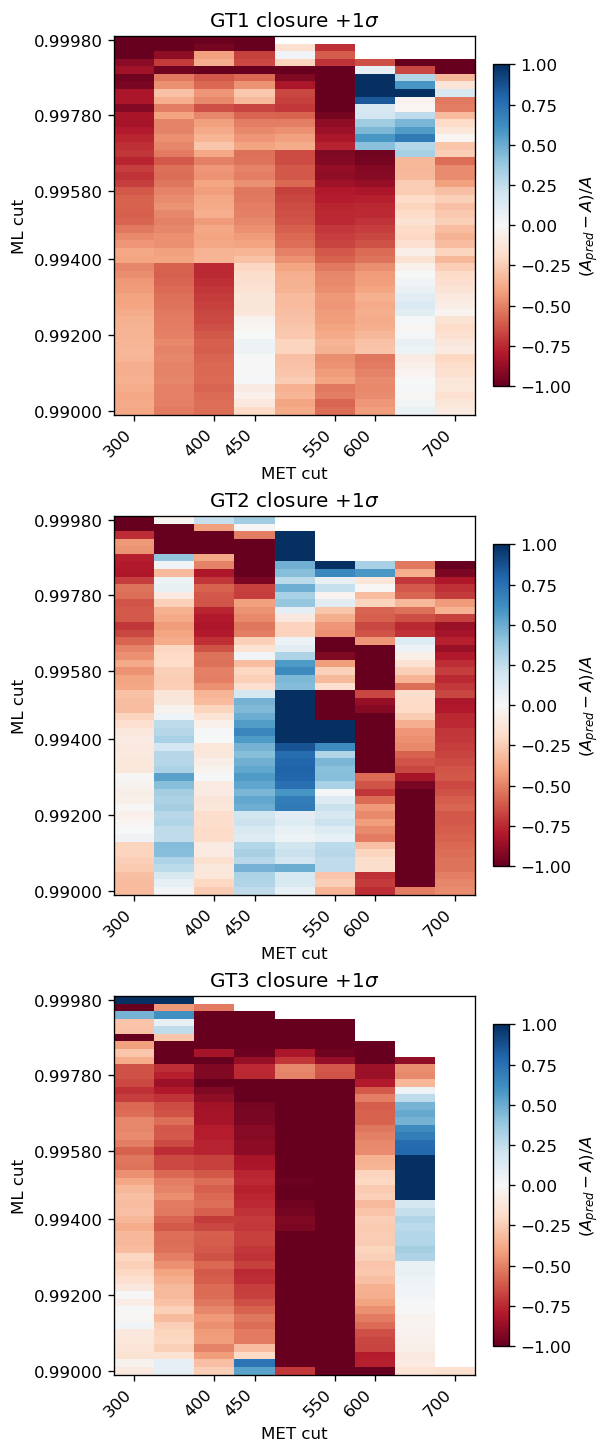

In [77]:
fig, axes = plt.subplots(3, 1, figsize=(5, 12), constrained_layout=True)

for ax, plane in zip(axes, PLANES):
    closure = -(closure_tables[plane]["delta_A"] +
                closure_tables[plane]["delta_A_unc"]) / closure_tables[plane]["bkg_NA"]
    heatmap(
        ax,
        closure,
        title=f"{plane} closure +1$\sigma$",
        cbar_label=r"$(A_{pred} - A) / A$",
        cmap="RdBu",
        vmin=-1.0,
        vmax=1.0,
    )

# fig.suptitle(f"ABCD closure, {YEAR} background scaled by {YIELD_SCALE}", y=1.05)
plt.show()


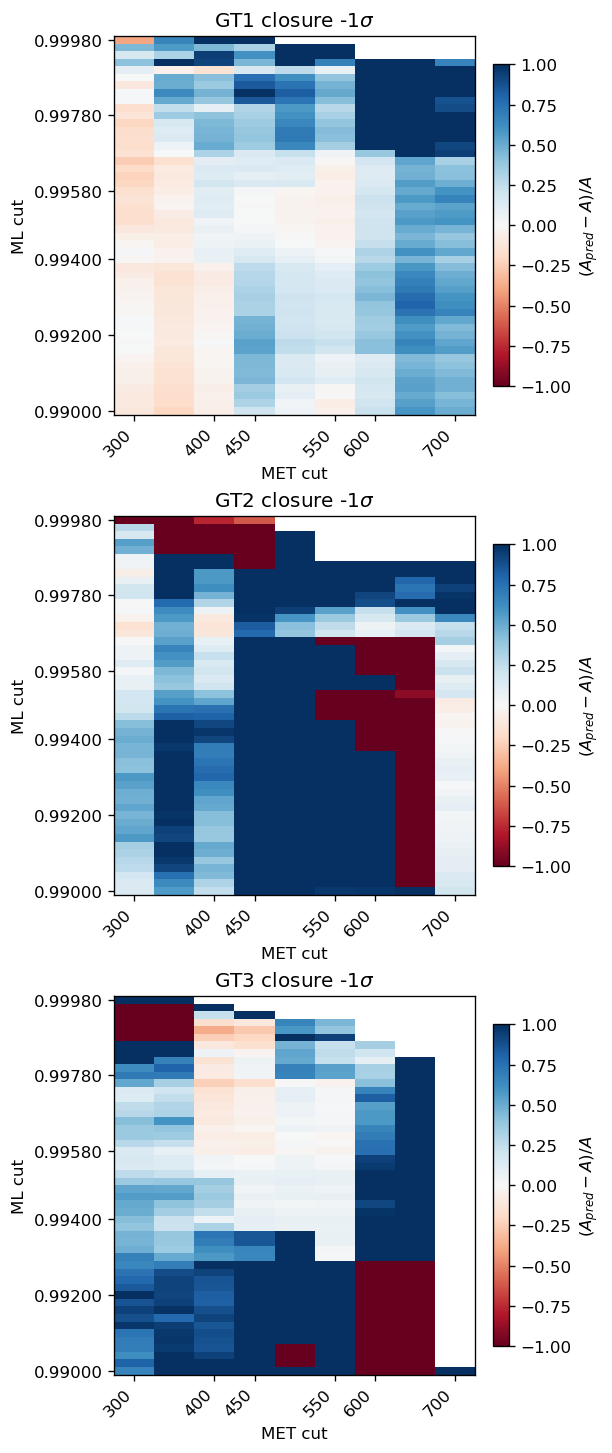

In [78]:
fig, axes = plt.subplots(3, 1, figsize=(5, 12), constrained_layout=True)

for ax, plane in zip(axes, PLANES):
    closure = -(closure_tables[plane]["delta_A"] -
                closure_tables[plane]["delta_A_unc"]) / closure_tables[plane]["bkg_NA"]
    heatmap(
        ax,
        closure,
        title=f"{plane} closure -1$\sigma$",
        cbar_label=r"$(A_{pred} - A) / A$",
        cmap="RdBu",
        vmin=-1.0,
        vmax=1.0,
    )

# fig.suptitle(f"ABCD closure, {YEAR} background scaled by {YIELD_SCALE}", y=1.05)
plt.show()


In [79]:
np.abs(closure_tables['GT2']['bkg_NA'] / closure_tables['GT3']['bkg_NA_unc'])

,0.9900,0.9902,0.9904,0.9906,0.9908,0.9910,0.9912,0.9914,0.9916,0.9918,...,0.9980,0.9982,0.9984,0.9986,0.9988,0.9990,0.9992,0.9994,0.9996,0.9998
300.0,14.215767,14.261513,13.941326,13.065423,13.218721,12.763045,12.572844,9.842546,10.035202,10.111698,...,3.909203,4.069037,4.148595,3.966858,4.333995,4.266301,4.419318,4.777970,3.974685,3.260875
350.0,6.855342,6.503687,6.213179,5.519784,5.594337,5.118192,4.938577,4.918224,4.946533,4.787665,...,1.596909,1.282083,1.745163,1.236201,1.093823,0.229361,0.736953,0.410003,0.728531,11.932376
400.0,7.166440,6.721856,6.296244,5.950392,6.977722,6.389616,6.133450,5.958447,5.813171,5.642750,...,2.847911,2.666730,6.438449,3.287197,2.586911,1.156344,1.749542,4.270439,8.571417,2.085261
450.0,3.293261,3.118807,3.284089,2.815852,3.662141,3.434733,3.401164,3.301107,3.126425,2.995792,...,2.525839,2.627527,2.379661,0.485005,0.980773,2.451966,2.545740,8.841982,2.085261,2.085261
500.0,2.301317,2.103967,2.031811,1.553311,2.265511,2.148939,2.114443,2.011365,1.909926,1.809895,...,2.620263,2.625103,2.178262,1.936583,1.163349,0.643491,0.643491,0.176958,0.000000,0.000000
550.0,1.703638,1.470322,1.470322,0.906644,1.079371,1.027631,0.984582,0.906991,0.830817,0.775915,...,1.577847,1.432893,0.909048,0.561285,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
600.0,2.248363,1.911888,1.911888,0.903352,0.903352,0.903352,0.903734,0.787773,0.673444,0.591041,...,1.445086,1.252256,0.759305,0.864814,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
650.0,0.053314,0.181939,0.181939,0.181939,0.181939,0.181939,0.181939,0.301010,0.301010,0.301010,...,3.166867,2.744285,0.211783,0.202889,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
700.0,9.448617,2.565580,2.565580,2.565580,2.565580,2.565580,2.565580,2.297114,2.297114,2.297114,...,0.272226,0.211783,0.211783,0.202889,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [80]:
# from uncertainties import ufloat

# x = 550
# y = 0.8400

# A = ufloat(closure_tables['GT3']['bkg_NA'].loc[x,y], closure_tables['GT3']['bkg_NA_unc'].loc[x,y])
# B = ufloat(closure_tables['GT3']['bkg_NB'].loc[x,y], closure_tables['GT3']['bkg_NB_unc'].loc[x,y])
# C = ufloat(closure_tables['GT3']['bkg_NC'].loc[x,y], closure_tables['GT3']['bkg_NC_unc'].loc[x,y])
# D = ufloat(closure_tables['GT3']['bkg_ND'].loc[x,y], closure_tables['GT3']['bkg_ND_unc'].loc[x,y])

# dA = A - B*C/D

# print(dA.n, "+/-", dA.s)
# print(A.n, "+/-", A.s)
# print(B.n, "+/-", B.s)
# print(C.n, "+/-", C.s)
# print(D.n, "+/-", D.s)

In [81]:
# t = A - B*ufloat(0,1)/D

# print(t.n, "+/-", t.s)

In [82]:
# B*C/D

In [83]:
# print(closure_tables['GT3']['delta_A'].loc[x,y], "+/-", closure_tables['GT3']['delta_A_unc'].loc[x,y])

## Combined significance scan

In [84]:
significance_tables['GT1']["Z_A_pred"].loc[450,0.9980]

0.31552007528154175

In [85]:
significance_tables['GT1']["bkg_ND"].loc[450,0.9980]

26325.2652168279

In [86]:
significance_tables['GT3']["Z_A_pred"].loc[450,0.9980]

1.5235340640415427

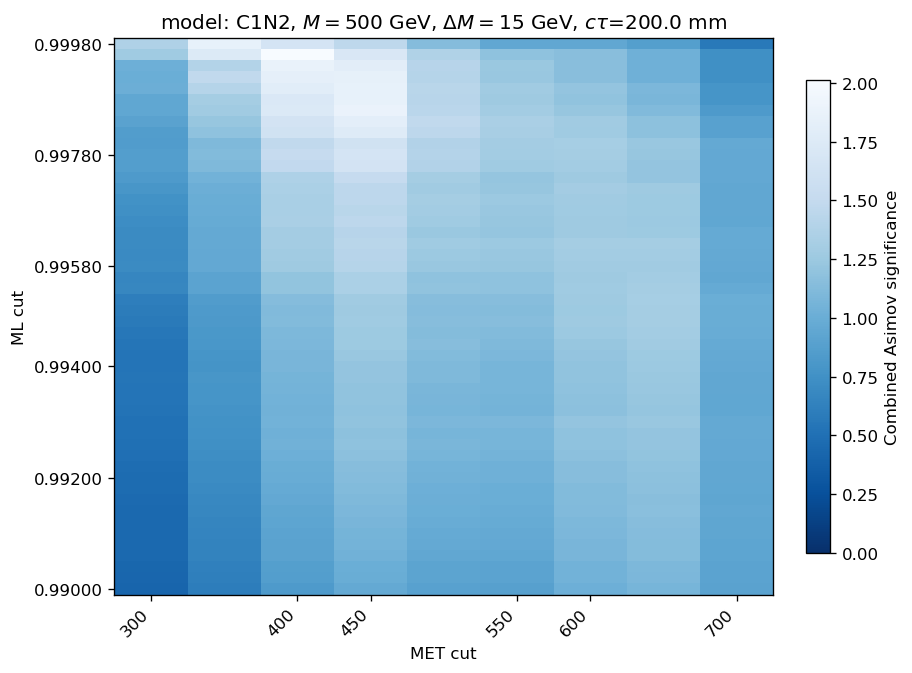

In [87]:
combined_z = np.sqrt(sum(significance_tables[plane]["Z_A_pred"].pow(2) for plane in PLANES))

fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
heatmap(
    ax,
    combined_z,
    title=f"model: {sample_info.model}, $M=${sample_info.M} GeV, $\Delta M=${sample_info.dM} GeV, $c\\tau$={TARGET_CTAU} mm", # : cτ {ORIGIN_CTAU:g} → {TARGET_CTAU:g} mm",
    cbar_label=r"Combined Asimov significance",# , $\sqrt{\sum_i Z_i^2}$",
    cmap="Blues_r",
    vmin=0.0,
    vmax=np.nanmax(combined_z.to_numpy(dtype=float)),
)
plt.savefig(f"{PLOT_OUTDIR /  SIGNAL_PKL.stem}_significance.pdf")
plt.show()

In [88]:
best_met, best_ml = combined_z.stack().idxmax()
print(f"Best combined significance: {combined_z.loc[best_met, best_ml]:.3f}")
print(f"MET cut: {best_met:g}")
print(f"ML cut:  {best_ml:.5f}")

for plane in PLANES:
    print(f"{plane}: Z_A_pred = {significance_tables[plane]['Z_A_pred'].loc[best_met, best_ml]:.3f}")


Best combined significance: 2.013
MET cut: 400
ML cut:  0.99960
GT1: Z_A_pred = 0.376
GT2: Z_A_pred = 0.322
GT3: Z_A_pred = 1.952
